# Infra-Bayesian vs Bayesian Multi-Armed Bandit

## The Setup

Two casinos exist. They are **exact mirror images** of each other:

| Casino | Arm 0 | Arm 1 |
|--------|-------|-------|
| **Red** | Safe — fixed $p = 0.5$ | Risky — $p \in \{0.1, 0.9\}$, unknown |
| **Blue** | Risky — $p \in \{0.1, 0.9\}$, unknown | Safe — fixed $p = 0.5$ |

The Risky arm's true probability is drawn from a **bimodal prior**: 50% chance $p=0.1$
(terrible) and 50% chance $p=0.9$ (excellent). Because the prior mean equals the Safe
arm's probability (both 0.5), the two arms look **completely identical at $t=0$**.
The agent cannot observe the casino colour.

**Omega** — the adversary — observes the agent's full deterministic policy *before*
the episode starts, then commits **once** to whichever casino gives the agent the
lower total expected reward over $T=5$ steps.

| Agent | Belief about casino | Objective |
|-------|---------------------|-----------|
| **Bayesian** | Nature chose it 50/50 | Maximise expected reward |
| **IB (Pareto DP)** | Omega chose it adversarially | Maximise *worst-case* expected reward |

### Why the bimodal prior matters
With $p \in \{0.1, 0.9\}$, even one or two pulls are enough to identify which arm is
the Risky one. This makes the *exploration choice* high-stakes: pulling the Safe arm
first wastes your entire identification budget. For any deterministic Bayesian
tie-breaking, Omega picks the casino that makes the chosen first arm the Safe one.

### What gets fixed when, and what the agent updates

It is worth being explicit about the timeline, because the IB framing makes it
sound as if Omega is doing something mid-episode. It is not.

- **Before $t=0$, Omega acts once.** It reads the agent's full deterministic
  policy and commits to the casino (Red or Blue) that minimises the agent's
  total expected reward. The Risky arm's true probability $p \in \{0.1, 0.9\}$
  is also drawn once from the bimodal prior. After this, both are fixed for
  the entire episode.
- **During $t = 0, \dots, T-1$**, the agent plays $T$ Bernoulli pulls inside
  the (now fixed) casino. The only quantity the agent updates online is the
  posterior over the Risky arm's $p$, which is ordinary Bayesian updating
  within a single casino — no Knightian update is needed.
- **One episode, length $T$.** Not multiple episodes; the headline numbers
  below are exact expectations over a single $T$-step play.

### Why aren't the casinos indistinguishable to the agent?

In one-step expected reward they are: prior mean of Risky $=0.5=$ Safe. But a
deterministic policy of length $T$ must commit to pulling either Arm 0 or
Arm 1 first, and *that* commitment breaks the symmetry — the same policy
yields different trajectory distributions in Red vs. Blue. Omega exploits
exactly this asymmetry.

### Where is the affine ($b$-term) part of full IB?

It is not needed here, by construction. The $b$-term in the full theory
keeps past-self and present-self consistent when the agent updates its
belief *over the Knightian piece* mid-episode. In this setup Omega
commits at $t=0$ and never revises, so the only mid-episode update is over
ordinary statistical uncertainty (within a single casino) and reduces to
Bayes' rule. This notebook therefore exercises the **policy-selection /
maximin** side of IB (the outer $\inf$ over $\Psi = \{m_\text{Red},
m_\text{Blue}\}$) but not the IB update rule of paper §2.7. The harder
regime — Omega cannot read the full policy and must infer it from
observed behaviour, so the agent must update over $\Psi$ — does require
the $b$-term and is not implemented here.

## 1. Setup and Helpers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time

# ── Parameters ────────────────────────────────────────────────────────────────
T         = 5
SAFE_PROB = 0.5
PV        = np.array([0.1, 0.9])   # bimodal: Risky arm is either terrible or excellent
PW        = np.array([0.5, 0.5])   # equal prior weight on each
P_RED     = 0.5                    # Bayesian agent's prior over Red vs Blue casino

# ── Mathematical helpers ───────────────────────────────────────────────────────
def M(n, s):
    """Marginal likelihood: sum_p w_p * p^s * (1-p)^(n-s)."""
    return float(np.sum(PW * (PV ** s) * ((1 - PV) ** (n - s))))

def E_risky(n, s):
    """Posterior expected success probability of the Risky arm after n pulls, s successes."""
    return float(PW @ PV) if n == 0 else M(n + 1, s + 1) / M(n, s)

def posterior_red(n0, s0, n1, s1):
    """P(Red Casino | history) starting from a 50/50 prior.
       Red: arm0=Safe, arm1=Risky.  Blue: arm0=Risky, arm1=Safe.
    """
    L_red  = P_RED       * (SAFE_PROB ** n0) * M(n1, s1)
    L_blue = (1 - P_RED) * M(n0, s0) * (SAFE_PROB ** n1)
    return L_red / (L_red + L_blue)

# ── Exact evaluator ────────────────────────────────────────────────────────────
def evaluate(policy, is_red, T=T):
    """Exact per-step expected reward for (policy, casino).

    Marginalises over the bimodal prior on the Risky arm. The inner dict ``sd``
    is the *outcome* distribution over sufficient statistics induced by the
    deterministic policy and the true reward probabilities (not the agent's
    posterior). Returns an array of length T."""
    per_step = np.zeros(T)
    for p_true, w in zip(PV, PW):
        p_arm = [SAFE_PROB, p_true] if is_red else [p_true, SAFE_PROB]
        sd = defaultdict(float); sd[(0, 0, 0, 0)] = 1.0
        for t in range(T):
            nd = defaultdict(float); sr = 0.0
            for state, prob in sd.items():
                if prob < 1e-15: continue
                n0, s0, n1, s1 = state
                a = policy[state]; ps = p_arm[a]
                sr += prob * ps
                if a == 0:
                    nd[(n0+1,s0+1,n1,  s1  )] += prob * ps
                    nd[(n0+1,s0,  n1,  s1  )] += prob * (1 - ps)
                else:
                    nd[(n0,  s0,  n1+1,s1+1)] += prob * ps
                    nd[(n0,  s0,  n1+1,s1  )] += prob * (1 - ps)
            per_step[t] += sr * w; sd = nd
    return per_step

print(f"T={T}, Safe arm p={SAFE_PROB}, Risky arm prior: {dict(zip(PV.tolist(), PW.tolist()))}")
print(f"Prior mean of Risky arm = {float(PW@PV):.2f}  (= Safe arm → arms look identical at t=0)")
print()
print("How fast the bimodal prior concentrates after a few pulls:")
for n, s in [(1,1),(2,2),(1,0),(2,0)]:
    e = E_risky(n, s)
    verdict = '→ almost certainly 0.9' if e>0.7 else '→ almost certainly 0.1'
    print(f"  E[p | {s}/{n} successes] = {e:.3f}  {verdict}")


T=5, Safe arm p=0.5, Risky arm prior: {0.1: 0.5, 0.9: 0.5}
Prior mean of Risky arm = 0.50  (= Safe arm → arms look identical at t=0)

How fast the bimodal prior concentrates after a few pulls:
  E[p | 1/1 successes] = 0.820  → almost certainly 0.9
  E[p | 2/2 successes] = 0.890  → almost certainly 0.9
  E[p | 0/1 successes] = 0.180  → almost certainly 0.1
  E[p | 0/2 successes] = 0.110  → almost certainly 0.1


## 2. Bayesian DP

The Bayesian agent assumes the casino was chosen randomly (50/50) and picks the arm
that maximises expected reward under this averaged belief.

**Why standard backward induction works here:** the Bayesian objective is a *linear*
combination of casino values. Linear objectives have independent subproblems — the
principle of optimality applies cleanly.


In [2]:
def solve_bayes_dp(T=T):
    V = {}; policy = {}
    for n0 in range(T+1):
        for s0 in range(n0+1):
            for n1 in range(T-n0+1):
                for s1 in range(n1+1):
                    if n0+n1 == T: V[(n0,s0,n1,s1)] = 0.0

    for t in range(T-1, -1, -1):
        for n0 in range(t+1):
            for s0 in range(n0+1):
                n1 = t - n0
                for s1 in range(n1+1):
                    state = (n0,s0,n1,s1)
                    pr  = posterior_red(*state)
                    er0 = E_risky(n0, s0); er1 = E_risky(n1, s1)
                    # Expected success prob under joint posterior
                    p0 = pr * SAFE_PROB + (1 - pr) * er0   # arm0: Safe if Red, Risky if Blue
                    p1 = pr * er1       + (1 - pr) * SAFE_PROB  # arm1: Risky if Red, Safe if Blue
                    q0 = p0*(1+V[(n0+1,s0+1,n1,s1)]) + (1-p0)*V[(n0+1,s0,n1,s1)]
                    q1 = p1*(1+V[(n0,s0,n1+1,s1+1)]) + (1-p1)*V[(n0,s0,n1+1,s1)]
                    if q0 >= q1: policy[state]=0; V[state]=q0
                    else:        policy[state]=1; V[state]=q1
    return policy, V

bayes_policy, bayes_V = solve_bayes_dp()
r_bayes_red  = evaluate(bayes_policy, is_red=True)
r_bayes_blue = evaluate(bayes_policy, is_red=False)

print(f"Bayesian DP solved.")
print(f"  Assumed value (50/50 Nature)  : {bayes_V[(0,0,0,0)]:.4f}")
print(f"  Actual value in Red Casino    : {r_bayes_red .sum():.4f}")
print(f"  Actual value in Blue Casino   : {r_bayes_blue.sum():.4f}")
print(f"  Worst-case (min)              : {min(r_bayes_red.sum(), r_bayes_blue.sum()):.4f}")
print(f"  Exploitable gap               : {abs(r_bayes_red.sum()-r_bayes_blue.sum()):.4f}  ← Omega can exploit this")


Bayesian DP solved.
  Assumed value (50/50 Nature)  : 2.9000
  Actual value in Red Casino    : 2.7800
  Actual value in Blue Casino   : 3.0200
  Worst-case (min)              : 2.7800
  Exploitable gap               : 0.2400  ← Omega can exploit this


## 3. Pareto DP — The IB Solver

### Why a scalar value function is not enough

The Bayesian DP works because its objective
$V(\pi) = \tfrac12 V^{\mathrm{Red}}(\pi) + \tfrac12 V^{\mathrm{Blue}}(\pi)$
is **linear** in the per-environment values, so a single scalar $V(s)$ at each
state is a sufficient statistic for the rest of the tree. The IB objective
$\min(V^{\mathrm{Red}}(\pi), V^{\mathrm{Blue}}(\pi))$ is **non-linear**: an
action that looks suboptimal under one casino in isolation can become optimal
if it raises the *worst* casino value. To plan correctly we need to know, at
every state, all the $(V^{\mathrm{Red}}, V^{\mathrm{Blue}})$ tradeoffs the tail
policy can still achieve — not just one number.

### The key idea

Instead of storing a single value $V(s)$ at each state, store the **Pareto frontier**
of all $(V^\text{Red}, V^\text{Blue})$ pairs achievable by any tail policy from $s$:

$$\text{Pareto}(s) = \{(V^\text{Red}(\pi_{\geq s}),\; V^\text{Blue}(\pi_{\geq s})) : \pi_{\geq s} \in \Pi\}_{\text{non-dominated}}$$

A pair $(v_r, v_b)$ is *non-dominated* (Pareto-optimal) if no other achievable pair
beats it on both coordinates.

### Backward induction on Pareto sets

At a terminal state, Pareto$(s)$ = $\{(0, 0)\}$.

At an intermediate state with current arm posteriors $p_r^a, p_b^a$ (success probs
for action $a$ in Red and Blue):

$$
\text{Pareto}(s) = \text{ParetoFrontier}\Bigg(
\bigcup_{a \in \{0,1\}}
\Big\{
\big(p_r^a(1+r_1^r) + (1-p_r^a)r_2^r,\;
     p_b^a(1+r_1^b) + (1-p_b^a)r_2^b\big)
\;:\;
(r_1^r,r_1^b) \in \text{Pareto}(s_{\text{succ}}^a),\;
(r_2^r,r_2^b) \in \text{Pareto}(s_{\text{fail}}^a)
\Big\}
\Bigg)
$$

where $(r_1^r, r_1^b)$ is the value pair if the chosen action *succeeds*
and $(r_2^r, r_2^b)$ the pair if it *fails*, in Red and Blue respectively.

At the root, pick the point on Pareto$((0,0,0,0))$ that maximises $\min(v_r, v_b)$.

### Why this is exact

The Pareto set at each state is the *complete* description of all achievable
$(V^\text{Red}, V^\text{Blue})$ tradeoffs. The cross-product over successor states
captures all possible combinations of sub-policies. The result is a **globally
optimal** deterministic policy.

### Feasibility

At $T=5$ the root frontier has $\sim 60$ points and the algorithm runs in a few
milliseconds. The cross-product step is $O(|F_{\text{succ}}| \times |F_{\text{fail}}|)$
per action per state, so frontier size can in principle grow combinatorially with
$T$; this proof-of-concept does not characterise scaling beyond $T=5$.

In [3]:
def pareto_frontier(candidates, eps=1e-10):
    """
    Keep only Pareto-optimal (vr, vb) pairs (maximising both).
    candidates: list of (vr, vb, action, succ_idx, fail_idx)
    Returns list sorted by vr descending (vb therefore ascending on the frontier).
    """
    # Dedup at the same precision used for dominance comparison.
    decimals = max(0, int(round(-np.log10(eps))))
    seen = {}
    for item in candidates:
        key = (round(item[0], decimals), round(item[1], decimals))
        if key not in seen:
            seen[key] = item
    pts = sorted(seen.values(), key=lambda x: (-x[0], x[1]))
    frontier = []; max_vb = -1.0
    for item in pts:
        if item[1] > max_vb + eps:
            frontier.append(item)
            max_vb = item[1]
    return frontier

def solve_pareto_dp(T=T):
    """
    Pareto DP for the IB bandit.
    pareto[state] = list of (vr, vb, action, succ_idx, fail_idx)
    The succ/fail indices point into the Pareto lists of the successor states,
    enabling exact policy extraction by backtracking.
    """
    pareto = {}

    # Base case: terminal states have zero future reward
    for n0 in range(T+1):
        for s0 in range(n0+1):
            for n1 in range(T-n0+1):
                for s1 in range(n1+1):
                    if n0+n1 == T:
                        pareto[(n0,s0,n1,s1)] = [(0.0, 0.0, None, None, None)]

    # Backward induction
    for t in range(T-1, -1, -1):
        for n0 in range(t+1):
            for s0 in range(n0+1):
                n1 = t - n0
                for s1 in range(n1+1):
                    state = (n0,s0,n1,s1)
                    er0 = E_risky(n0, s0)   # arm0 as Risky (true in Blue)
                    er1 = E_risky(n1, s1)   # arm1 as Risky (true in Red)
                    candidates = []

                    # ── Action 0: arm0 success probs = SAFE(Red), er0(Blue)
                    ss0 = (n0+1,s0+1,n1,  s1  )
                    sf0 = (n0+1,s0,  n1,  s1  )
                    pr0, pb0 = SAFE_PROB, er0
                    for i, (r1r,r1b,*_) in enumerate(pareto[ss0]):
                        for j, (r2r,r2b,*_) in enumerate(pareto[sf0]):
                            vr = pr0*(1+r1r) + (1-pr0)*r2r
                            vb = pb0*(1+r1b) + (1-pb0)*r2b
                            candidates.append((vr, vb, 0, i, j))

                    # ── Action 1: arm1 success probs = er1(Red), SAFE(Blue)
                    ss1 = (n0,s0,n1+1,s1+1)
                    sf1 = (n0,s0,n1+1,s1  )
                    pr1, pb1 = er1, SAFE_PROB
                    for i, (r1r,r1b,*_) in enumerate(pareto[ss1]):
                        for j, (r2r,r2b,*_) in enumerate(pareto[sf1]):
                            vr = pr1*(1+r1r) + (1-pr1)*r2r
                            vb = pb1*(1+r1b) + (1-pb1)*r2b
                            candidates.append((vr, vb, 1, i, j))

                    pareto[state] = pareto_frontier(candidates)

    return pareto


import timeit
elapsed = min(timeit.repeat(lambda: solve_pareto_dp(T), repeat=5, number=1))
pareto = solve_pareto_dp(T)

root_frontier = pareto[(0,0,0,0)]
print(f"Pareto DP solved in {elapsed*1000:.2f} ms (best of 5)")
print(f"Root frontier size: {len(root_frontier)} points")
print()

# Find IB-optimal point on root frontier
best_min = -1.0; best_idx = 0
for k, (vr, vb, *_) in enumerate(root_frontier):
    if min(vr, vb) > best_min:
        best_min = min(vr, vb); best_idx = k

print(f"IB guaranteed value: {best_min:.4f}")
print()

# Frontier size by depth
sizes = defaultdict(list)
for (n0,s0,n1,s1), pts in pareto.items():
    t = n0+n1
    if t < T:
        sizes[t].append(len(pts))
print("Pareto frontier sizes by depth t:")
for t in sorted(sizes):
    s = sizes[t]
    print(f"  t={t}: max={max(s):3d}, mean={np.mean(s):.1f}, states={len(s)}")


Pareto DP solved in 3.44 ms (best of 5)
Root frontier size: 60 points

IB guaranteed value: 2.8472

Pareto frontier sizes by depth t:
  t=0: max= 60, mean=60.0, states=1
  t=1: max= 19, mean=15.2, states=4
  t=2: max= 12, mean=6.1, states=10
  t=3: max=  6, mean=2.6, states=20
  t=4: max=  2, mean=1.5, states=35


## 4. Extracting the Optimal Policy

The Pareto DP stores backpointers: for each point on a state's frontier, we know
which action was taken and which points in the successor states' frontiers were used.
Starting from the root's IB-optimal point, we backtrack to reconstruct the full
deterministic policy.


In [4]:
def extract_policy(pareto, T=T):
    """Backtrack from the root's IB-optimal Pareto point to recover the policy.

    Under any deterministic policy from (0,0,0,0), the success/failure subtrees
    of each state are disjoint (success bumps s_a, failure does not), so the
    reachable-state graph is a *tree*. We therefore visit each reachable state
    exactly once during backtracking, and need no consistency check.
    """
    # Pick the IB-optimal point on the root frontier.
    root_pts = pareto[(0,0,0,0)]
    best_idx = max(range(len(root_pts)), key=lambda k: min(root_pts[k][:2]))
    best_min = min(root_pts[best_idx][:2])

    policy = {}
    queue  = [((0,0,0,0), best_idx)]
    while queue:
        state, idx = queue.pop()
        n0, s0, n1, s1 = state
        _, _, action, succ_idx, fail_idx = pareto[state][idx]
        if action is None:           # terminal: nothing to record
            continue
        policy[state] = action
        if action == 0:
            ss = (n0+1, s0+1, n1,   s1  )
            sf = (n0+1, s0,   n1,   s1  )
        else:
            ss = (n0,   s0,   n1+1, s1+1)
            sf = (n0,   s0,   n1+1, s1  )
        queue.append((ss, succ_idx))
        queue.append((sf, fail_idx))

    return policy, best_min


ib_policy, ib_guaranteed = extract_policy(pareto, T)

r_ib_red  = evaluate(ib_policy, is_red=True)
r_ib_blue = evaluate(ib_policy, is_red=False)

print(f"IB policy extracted ({len(ib_policy)} reachable states).")
print(f"  V_Red  : {r_ib_red .sum():.4f}")
print(f"  V_Blue : {r_ib_blue.sum():.4f}")
print(f"  min    : {min(r_ib_red.sum(),r_ib_blue.sum()):.4f}  (matches DP: {ib_guaranteed:.4f})")


IB policy extracted (25 reachable states).
  V_Red  : 2.8584
  V_Blue : 2.8472
  min    : 2.8472  (matches DP: 2.8472)


## 5. Omega's Choice and Final Comparison


In [5]:
def omega_pick(r_red, r_blue, name):
    if r_red.sum() <= r_blue.sum():
        casino, r_worst = "Red",  r_red
    else:
        casino, r_worst = "Blue", r_blue
    print(f"  Omega vs {name:10s}→ picks {casino:4s} Casino  (total reward = {r_worst.sum():.4f})")
    return casino, r_worst

r_bayes_benign = 0.5 * r_bayes_red + 0.5 * r_bayes_blue

print("Omega's adversarial picks:")
omega_bayes_casino, r_bayes_worst = omega_pick(r_bayes_red,  r_bayes_blue,  "Bayesian  ")
omega_ib_casino,    r_ib_worst    = omega_pick(r_ib_red,     r_ib_blue,     "IB (Pareto)")

print()
print("Summary:")
print(f"  Bayesian | Benign Nature (50/50)  : {r_bayes_benign.sum():.4f}  ← Bayesian's own assumption")
print(f"  Bayesian | Adversarial Omega       : {r_bayes_worst .sum():.4f}  ← exploited")
print(f"  IB       | Adversarial Omega       : {r_ib_worst    .sum():.4f}  ← guaranteed lower bound")
print()
print(f"  Bayesian worst-case shortfall vs its own assumption : "
      f"{r_bayes_benign.sum() - r_bayes_worst.sum():.4f}")
print(f"  IB worst-case improvement over Bayesian worst-case  : "
      f"{r_ib_worst.sum() - r_bayes_worst.sum():.4f}")


Omega's adversarial picks:
  Omega vs Bayesian  → picks Red  Casino  (total reward = 2.7800)
  Omega vs IB (Pareto)→ picks Blue Casino  (total reward = 2.8472)

Summary:
  Bayesian | Benign Nature (50/50)  : 2.9000  ← Bayesian's own assumption
  Bayesian | Adversarial Omega       : 2.7800  ← exploited
  IB       | Adversarial Omega       : 2.8472  ← guaranteed lower bound

  Bayesian worst-case shortfall vs its own assumption : 0.1200
  IB worst-case improvement over Bayesian worst-case  : 0.0672


## 6. Results

### Plot 1 — The Pareto Frontier at the Root

The frontier shows every $(V^\text{Red}, V^\text{Blue})$ pair achievable by some
deterministic policy. Moving right along the frontier trades Blue value for Red value.

Key points marked:
- **Bayesian policy** — achieves a high Red-Blue gap; Omega exploits the lower coordinate
- **IB optimum** — the point on the frontier with the highest $\min(v_r, v_b)$, just
  before the crossing where $v_r = v_b$
- **Equal-value diagonal** ($v_r = v_b$) — any policy on this line would be perfectly
  unexploitable. Whether the deterministic-policy frontier reaches the diagonal exactly
  depends on the discretisation; in this setup the IB optimum lies just above it.


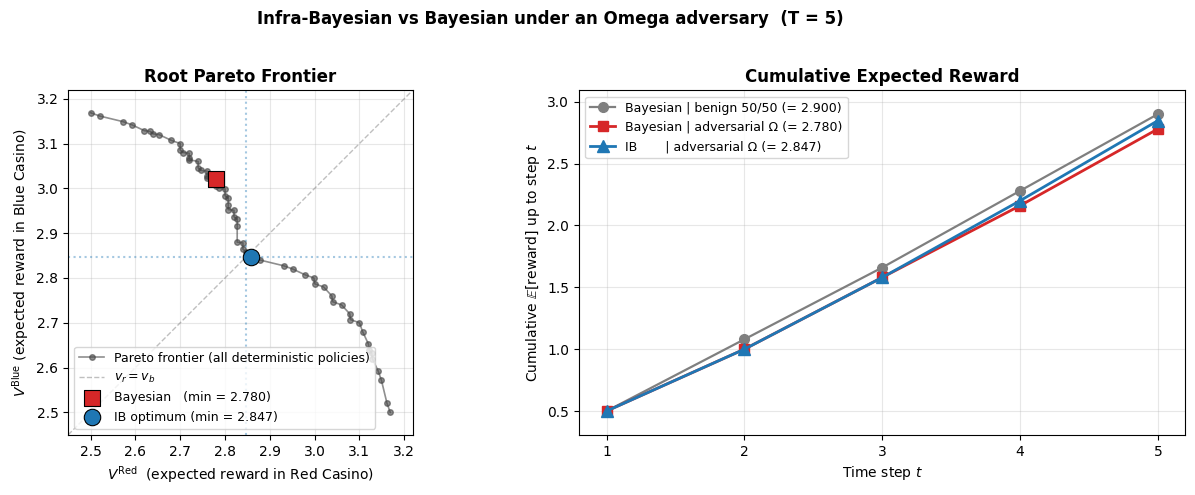

Final totals:
  Bayesian | benign Ω       : 2.9000
  Bayesian | adversarial Ω : 2.7800
  IB       | adversarial Ω : 2.8472


In [6]:
import numpy as np
steps = np.arange(1, T + 1)

# Cumulative trajectories (the headline numbers visualised over time).
cum_benign = np.cumsum(r_bayes_benign)
cum_bayes  = np.cumsum(r_bayes_worst)
cum_ib     = np.cumsum(r_ib_worst)

# ── Figure: Pareto frontier (left) + cumulative reward (right) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Infra-Bayesian vs Bayesian under an Omega adversary  (T = 5)",
             fontsize=12, fontweight="bold")

# ── Left panel: Pareto frontier ────────────────────────────────────────────────
ax = axes[0]
vrs = [pt[0] for pt in pareto[(0,0,0,0)]]
vbs = [pt[1] for pt in pareto[(0,0,0,0)]]
ax.plot(vrs, vbs, "o-", color="#444", ms=4, lw=1.2, alpha=0.6,
        label="Pareto frontier (all deterministic policies)")

# Diagonal v_r = v_b
lo = min(vrs + vbs) - 0.05
hi = max(vrs + vbs) + 0.05
d = np.linspace(lo, hi, 100)
ax.plot(d, d, "--", color="grey", alpha=0.5, lw=1, label=r"$v_r = v_b$")

# Bayesian and IB points (consistent colours with the right panel).
bvr, bvb = r_bayes_red.sum(), r_bayes_blue.sum()
ivr, ivb = r_ib_red.sum(),    r_ib_blue.sum()
ax.scatter([bvr], [bvb], s=140, color="#d62728", marker="s",
           edgecolor="black", lw=0.8, zorder=5,
           label=f"Bayesian   (min = {min(bvr,bvb):.3f})")
ax.scatter([ivr], [ivb], s=140, color="#1f77b4", marker="o",
           edgecolor="black", lw=0.8, zorder=5,
           label=f"IB optimum (min = {min(ivr,ivb):.3f})")

# Guides at IB min on both axes.
ax.axhline(min(ivr, ivb), color="#1f77b4", ls=":", alpha=0.4)
ax.axvline(min(ivr, ivb), color="#1f77b4", ls=":", alpha=0.4)

ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
ax.set_xlabel(r"$V^{\mathrm{Red}}$  (expected reward in Red Casino)")
ax.set_ylabel(r"$V^{\mathrm{Blue}}$ (expected reward in Blue Casino)")
ax.set_title("Root Pareto Frontier", fontweight="bold")
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, alpha=0.3)

# ── Right panel: cumulative expected reward ────────────────────────────────────
ax = axes[1]
ax.plot(steps, cum_benign, "o-", color="#7f7f7f", lw=1.6, ms=7,
        label=f"Bayesian | benign 50/50 (= {cum_benign[-1]:.3f})")
ax.plot(steps, cum_bayes,  "s-", color="#d62728", lw=2.0, ms=7,
        label=f"Bayesian | adversarial Ω (= {cum_bayes[-1]:.3f})")
ax.plot(steps, cum_ib,     "^-", color="#1f77b4", lw=2.0, ms=8,
        label=f"IB       | adversarial Ω (= {cum_ib[-1]:.3f})")

# Tight y-axis around the actual data, with a small margin.
ymin = min(cum_benign.min(), cum_bayes.min(), cum_ib.min())
ymax = max(cum_benign.max(), cum_bayes.max(), cum_ib.max())
margin = 0.08 * (ymax - ymin)
ax.set_ylim(ymin - margin, ymax + margin)
ax.set_xticks(steps)

ax.set_xlabel("Time step $t$")
ax.set_ylabel(r"Cumulative $\mathbb{E}[\mathrm{reward}]$ up to step $t$")
ax.set_title("Cumulative Expected Reward", fontweight="bold")
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("ib_bandit_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

print("Final totals:")
print(f"  Bayesian | benign Ω       : {cum_benign[-1]:.4f}")
print(f"  Bayesian | adversarial Ω : {cum_bayes[-1] :.4f}")
print(f"  IB       | adversarial Ω : {cum_ib[-1]   :.4f}")


## 7. Policy Inspection

The two policies share the same **structure**: pull one arm, and because the
bimodal $\{0.1, 0.9\}$ prior makes a single observation almost decisive,
*stay* on a winning arm and *switch* on a losing one. The headline difference
is at the root:

| Step | Bayesian | IB |
|------|----------|------|
| $t=0$ (tie at $0.5/0.5$) | Arm 0 | Arm 1 |
| after a success         | stay  | stay |
| after a failure         | switch | switch |

The Bayesian agent breaks the symmetric tie toward Arm 0 — which is the Safe
arm in the Red Casino. Omega exploits this by committing to Red, putting the
Bayesian on the Safe arm for the entire informative first pull. The IB agent
breaks the tie *the other way* and (in 5 deeper non-symmetric states) hedges
in further small ways that lift its worst-case cumulative reward from 2.78 to
2.85. The next cell prints the differences explicitly.


In [7]:
def reachable_states(policy, T=T):
    """States actually visited by a deterministic policy from (0,0,0,0)."""
    seen = set()
    frontier = [(0,0,0,0)]
    while frontier:
        st = frontier.pop()
        if st in seen or st not in policy:
            continue
        seen.add(st)
        n0, s0, n1, s1 = st
        if n0 + n1 == T:
            continue
        a = policy[st]
        if a == 0:
            frontier += [(n0+1,s0+1,n1,s1), (n0+1,s0,n1,s1)]
        else:
            frontier += [(n0,s0,n1+1,s1+1), (n0,s0,n1+1,s1)]
    return seen

R_b = reachable_states(bayes_policy)
R_i = reachable_states(ib_policy)

# Mirror map: swapping arm labels is a symmetry of the problem.
def mirror(s):  return (s[2], s[3], s[0], s[1])
def flip(a):    return 1 - a

mirror_bayes = {mirror(s): flip(a) for s, a in bayes_policy.items()}

# IB states where IB does NOT play the mirror-of-Bayesian action — the genuine
# IB hedges that lift the worst-case above the symmetric mirror policy.
hedges = sorted(s for s in R_i if mirror_bayes.get(s) != ib_policy[s])

arm = {0: "Arm 0", 1: "Arm 1"}
print("Root choice")
print(f"  Bayesian -> {arm[bayes_policy[(0,0,0,0)]]}")
print(f"  IB       -> {arm[ib_policy[(0,0,0,0)]]}")
print()
print(f"Reachable states: Bayesian {len(R_b)}, IB {len(R_i)}")
print()
print("IB-reachable states where IB differs from a pure mirror-of-Bayesian:")
print(f"  ({len(hedges)} states out of {len(R_i)} reachable -- the IB hedges)")
print(f"  {'state':14s} {'IB':>5s}  {'mirror(Bayes)':>13s}")
for s in hedges:
    print(f"  {str(s):14s} {arm[ib_policy[s]]:>5s}  {arm[mirror_bayes[s]]:>13s}")


Root choice
  Bayesian -> Arm 0
  IB       -> Arm 1

Reachable states: Bayesian 26, IB 25

IB-reachable states where IB differs from a pure mirror-of-Bayesian:
  (5 states out of 25 reachable -- the IB hedges)
  state             IB  mirror(Bayes)
  (0, 0, 3, 2)   Arm 0          Arm 1
  (1, 0, 2, 0)   Arm 1          Arm 0
  (1, 0, 3, 0)   Arm 1          Arm 0
  (2, 1, 2, 1)   Arm 0          Arm 1
  (3, 1, 1, 0)   Arm 1          Arm 0


## 8. Interpretation

### Why the Pareto DP is needed

The Bayesian objective is *linear* in the per-environment values, so subproblems
decouple and a scalar Bellman recursion suffices. The IB objective
$\min(V^{\text{Red}}, V^{\text{Blue}})$ is *non-linear*: subproblems are coupled,
and no scalar value function at a state captures enough information to act
optimally. Storing the full Pareto frontier of $(V^{\text{Red}}, V^{\text{Blue}})$
pairs at each state, and combining frontiers across (success, failure)
successors by cross-product, recovers the exact global optimum.

### Connection to the paper

- **Infradistribution.** $\Psi = \{m_{\text{Red}}, m_{\text{Blue}}\}$ — a
  two-element set of evaluators, the simplest non-trivial infradistribution.
- **Lower expectation.** For a policy $\pi$,
  $\underline{\mathbb{E}}_\Psi[V(\pi)] = \min(V^{\text{Red}}(\pi),\, V^{\text{Blue}}(\pi))$.
- **Finite extremal representation (paper §2.5).** The Pareto frontier at a
  state is the *finite set of non-dominated minimal points* needed to compute
  the lower expectation under any tail policy.
- **Worst-case guarantee.** Omega is a constructive instantiation of the
  paper's adversarial selection: it realises the infimum.
- **Recovery of Bayes (paper §2.6).** When $\Psi$ collapses to a single
  evaluator (e.g. setting $P_{\text{RED}} = 1$), the Pareto frontier becomes
  a single point and the IB agent reduces to the Bayesian one.

### Scope and limitations

This notebook is a deliberately small finite-outcome demo. It does not
implement IB-style updates of $a$-measures (paper §2.7) or signed
$a$-measures, and it scales as $O(|F_{\text{succ}}| \times |F_{\text{fail}}|)$
per state -- frontier sizes are tiny here ($\le 60$ at the root) but are not
characterised for larger horizons.
